#IMPORT THE LIBRARIES

In [ ]:
import gdown
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic

#for regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm #for VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor #for VIF

#IMPORT THE DATA

In [ ]:
url = "https://drive.google.com/file/d/1uXwMxJNE9pkKP_5zUhCPdMQPrhnBLdA7/view?usp=drive_link"
output = "ibm.csv"
gdown.download(url, output, quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1uXwMxJNE9pkKP_5zUhCPdMQPrhnBLdA7
To: /content/ibm.csv
100%|██████████| 228k/228k [00:00<00:00, 84.9MB/s]


'ibm.csv'

In [ ]:
ibm = pd.read_csv('/content/ibm.csv')
ibm

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


#CHANGING THE DATA TYPE

In [ ]:
ibm['OverTime'].loc[ibm['OverTime'] == "Yes"] = 1
ibm['OverTime'].loc[ibm['OverTime'] == "No"] = 0
ibm['OverTime'] = ibm['OverTime'].astype('int')
ibm['OverTime']

/tmp/ipykernel_1207/1923279250.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ibm['OverTime'].loc[ibm['OverTime'] == "Yes"] = 1
/tmp/ipykernel_1207/1923279250.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

,OverTime
0,1
1,0
2,1
3,1
4,0
...,...
1465,0
1466,0
1467,1
1468,0


In [ ]:
ibm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

#ENCODING THE CATEGORICAL VARIABLES

In [ ]:
ibm2 = ibm.copy()

In [ ]:
ibm2.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
#seeing the categorical columns to encode
categorical_columns = ibm2.select_dtypes(include='object').columns.to_list()
categorical_columns

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18']

In [ ]:
#encoding the categorical columns
ibm2 = pd.get_dummies(ibm2, columns = categorical_columns)

#check teh result of encoding
ibm2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 56 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   DailyRate                          1470 non-null   int64
 2   DistanceFromHome                   1470 non-null   int64
 3   Education                          1470 non-null   int64
 4   EmployeeCount                      1470 non-null   int64
 5   EmployeeNumber                     1470 non-null   int64
 6   EnvironmentSatisfaction            1470 non-null   int64
 7   HourlyRate                         1470 non-null   int64
 8   JobInvolvement                     1470 non-null   int64
 9   JobLevel                           1470 non-null   int64
 10  JobSatisfaction                    1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  MonthlyRate         

#FIND OUT THE CORRELATION

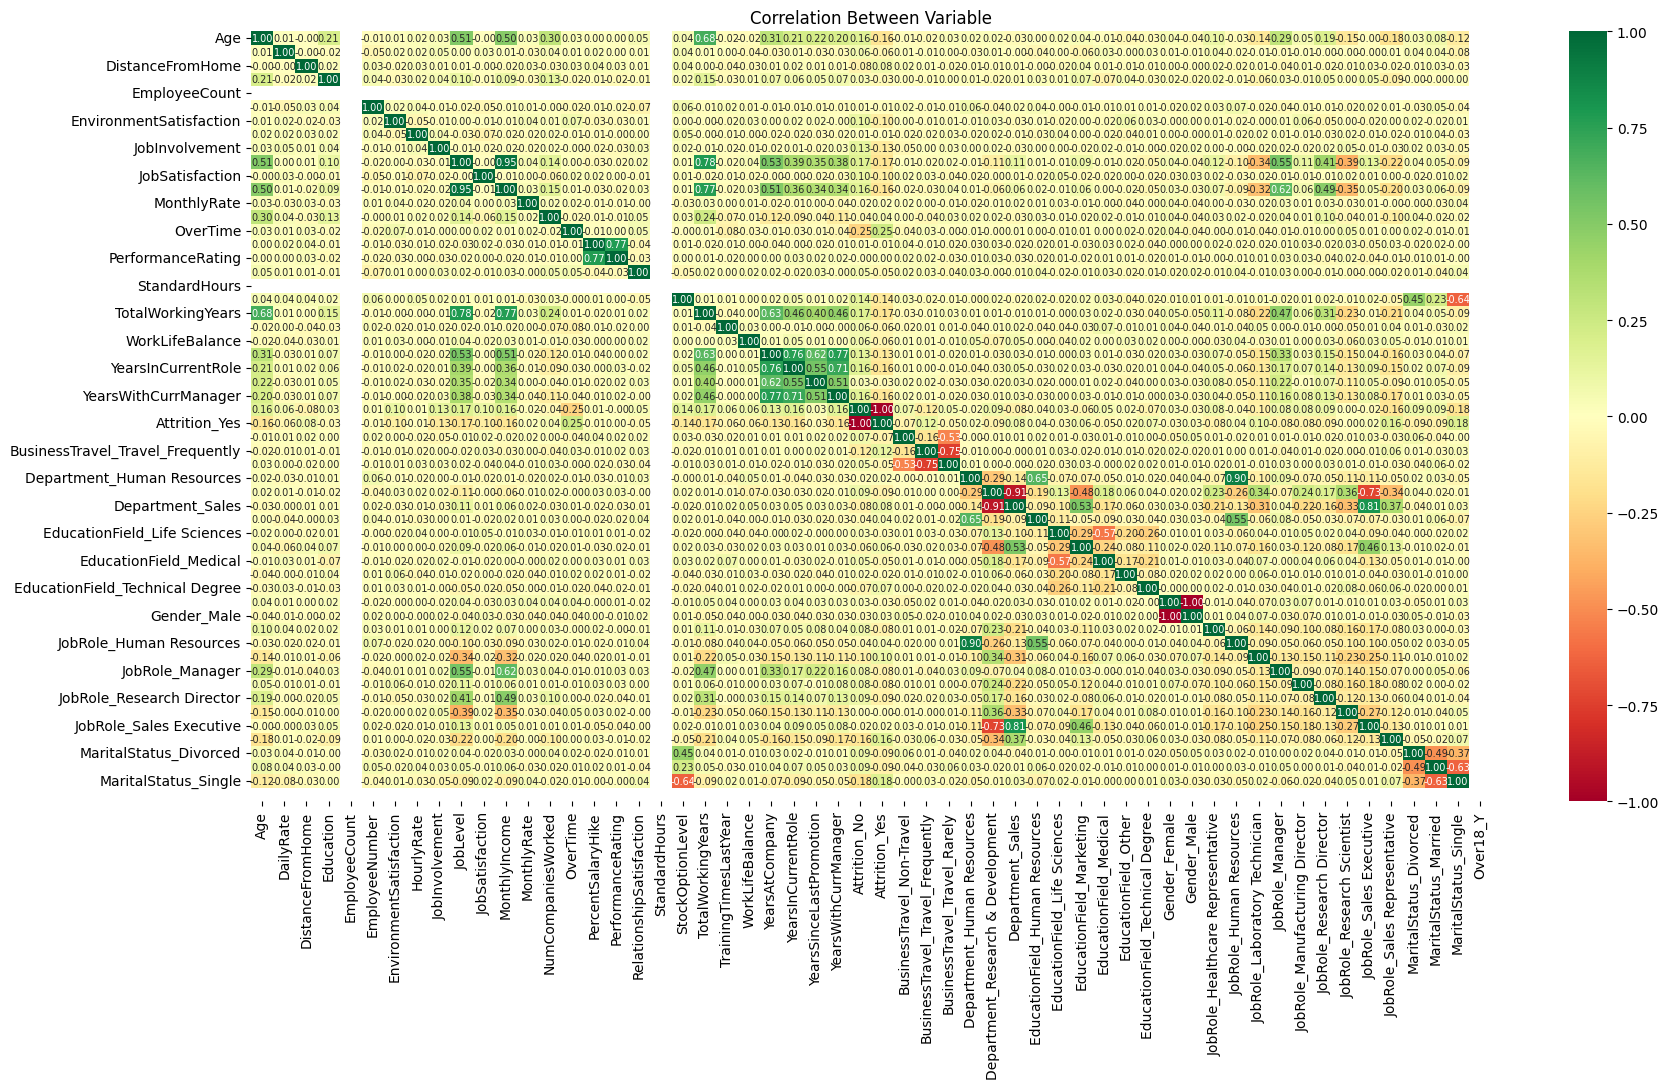

In [ ]:
#see the correlation in heatmap

fig = plt.figure(figsize=(20,10))

ax = fig.add_subplot(1, 1, 1)
ax.set_title('Correlation Between Variable')

sns.heatmap(ibm2.corr(),vmin=-1,
            vmax=1,cmap='RdYlGn',annot=True,
            annot_kws={"fontsize":7}, fmt=",.2f")

plt.show()


#THE 10 TEN CORELLATION TO ATTRITION

In [ ]:
#THE 10 TEN CORELLATION TO ATTRITION

selected_columns = ['Age', 'JobLevel', 'MonthlyIncome', 'OverTime', 'TotalWorkingYears', 'StockOptionLevel', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'JobRole_Sales Representative', 'MaritalStatus_Single', 'JobInvolvement', 'Attrition_Yes']

ibm3 = ibm2[selected_columns].copy()
ibm3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Age                           1470 non-null   int64
 1   JobLevel                      1470 non-null   int64
 2   MonthlyIncome                 1470 non-null   int64
 3   OverTime                      1470 non-null   int64
 4   TotalWorkingYears             1470 non-null   int64
 5   StockOptionLevel              1470 non-null   int64
 6   YearsAtCompany                1470 non-null   int64
 7   YearsInCurrentRole            1470 non-null   int64
 8   YearsWithCurrManager          1470 non-null   int64
 9   JobRole_Sales Representative  1470 non-null   bool 
 10  MaritalStatus_Single          1470 non-null   bool 
 11  JobInvolvement                1470 non-null   int64
 12  Attrition_Yes                 1470 non-null   bool 
dtypes: bool(3), int64(10)
memory usag

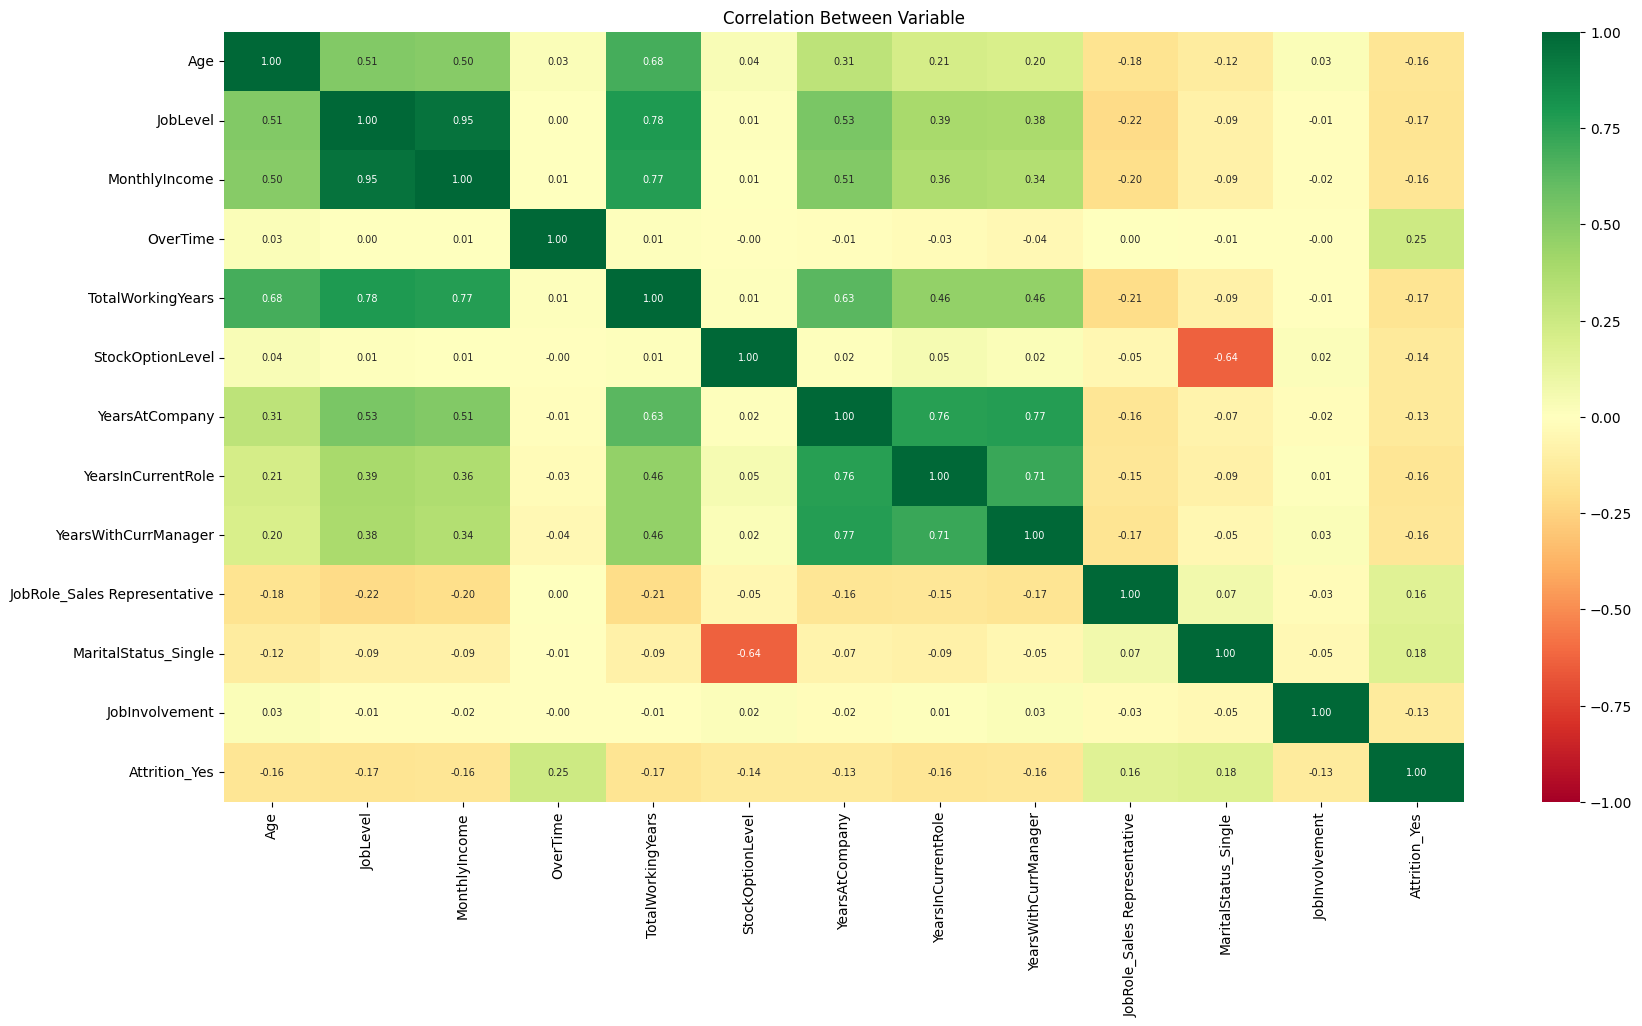

In [ ]:
#see the correlation in heatmap

fig = plt.figure(figsize=(20,10))

ax = fig.add_subplot(1, 1, 1)
ax.set_title('Correlation Between Variable')

sns.heatmap(ibm3.corr(),vmin=-1,
            vmax=1,cmap='RdYlGn',annot=True,
            annot_kws={"fontsize":7}, fmt=",.2f")

plt.show()


#CHOOSE THE FINAL VARIABLES

In [ ]:
selected_columns4 = ['MonthlyIncome', 'OverTime', 'StockOptionLevel', 'Attrition_Yes']
ibm4 = ibm3[selected_columns4].copy()
ibm4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   MonthlyIncome     1470 non-null   int64
 1   OverTime          1470 non-null   int64
 2   StockOptionLevel  1470 non-null   int64
 3   Attrition_Yes     1470 non-null   bool 
dtypes: bool(1), int64(3)
memory usage: 36.0 KB


In [ ]:
ibm4_with_const = sm.add_constant(ibm4)

In [ ]:
# Convert all data to float so statsmodels can perform the math
ibm4_with_const = ibm4_with_const.astype(float)

# make VIF data frame
vif = pd.DataFrame()
vif["Feature"] = ibm4_with_const.columns
vif["VIF"] = [variance_inflation_factor(ibm4_with_const.values, i) for i in range(ibm4_with_const.shape[1])]

vif

,Feature,VIF
0,const,4.595172
1,MonthlyIncome,1.028892
2,OverTime,1.068234
3,StockOptionLevel,1.020749
4,Attrition_Yes,1.117500


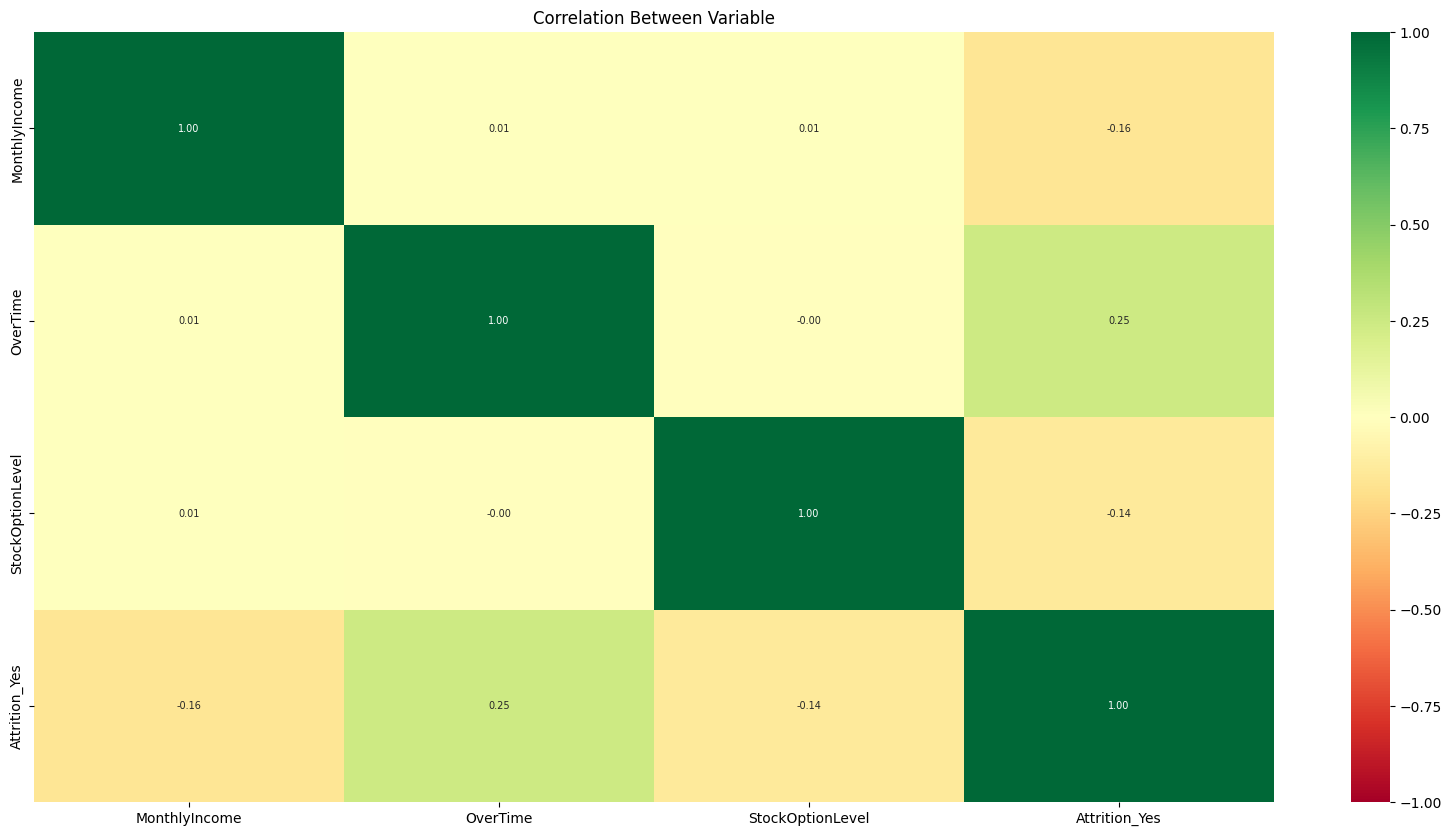

In [ ]:
#see the correlation in heatmap

fig = plt.figure(figsize=(20,10))

ax = fig.add_subplot(1, 1, 1)
ax.set_title('Correlation Between Variable')

sns.heatmap(ibm4.corr(),vmin=-1,
            vmax=1,cmap='RdYlGn',annot=True,
            annot_kws={"fontsize":7}, fmt=",.2f")

plt.show()

#LOGISTIC REGRESSION


##SPLIT X (FEATURE) AND Y (TARGET)

In [ ]:
#make new dataframes = x for features, y for target
x = ibm4.copy()
x = ibm4.drop(columns='Attrition_Yes')
y = ibm4['Attrition_Yes'].copy()

#check the x dataframe (features)
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   MonthlyIncome     1470 non-null   int64
 1   OverTime          1470 non-null   int64
 2   StockOptionLevel  1470 non-null   int64
dtypes: int64(3)
memory usage: 34.6 KB


In [ ]:
#check the y data frame
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1470 entries, 0 to 1469
Series name: Attrition_Yes
Non-Null Count  Dtype
--------------  -----
1470 non-null   bool 
dtypes: bool(1)
memory usage: 1.6 KB


##SPLIT TRAINING AND TEST

In [ ]:
#split X and Y to training and test

x_training, x_test, y_training, y_test = train_test_split(x,y,test_size = 0.3, random_state=10000)

In [ ]:
# Check split result
for df in [x_training, x_test, y_training, y_test]:
  print(df.shape)

(1029, 3)
(441, 3)
(1029,)
(441,)


##EDA ON TRAINING AND TEST

###DISTRIBUTION 0 AND 1

In [ ]:
# Let's combine training and test data in 1 df
training = pd.concat([x_training, y_training], axis=1)
test = pd.concat([x_test, y_test], axis=1)

In [ ]:
#check the training data frame
training

,MonthlyIncome,OverTime,StockOptionLevel,Attrition_Yes
1447,5406,0,1,False
492,15402,0,1,False
1186,4581,1,0,True
833,2539,0,1,False
295,13525,0,1,False
...,...,...,...,...
2,2090,1,0,True
1327,13225,0,1,False
296,1420,0,0,True
1439,7644,0,2,False


In [ ]:
#check the test data frame
test

,MonthlyIncome,OverTime,StockOptionLevel,Attrition_Yes
785,10322,0,1,False
1390,2367,0,1,True
1347,3886,0,0,False
319,5228,1,0,False
556,2450,0,0,False
...,...,...,...,...
321,7547,0,3,False
1281,5813,1,0,True
810,17465,0,1,False
49,2269,0,0,False


[Text(0, 0, '0.838678'), Text(0, 0, '0.161322')]

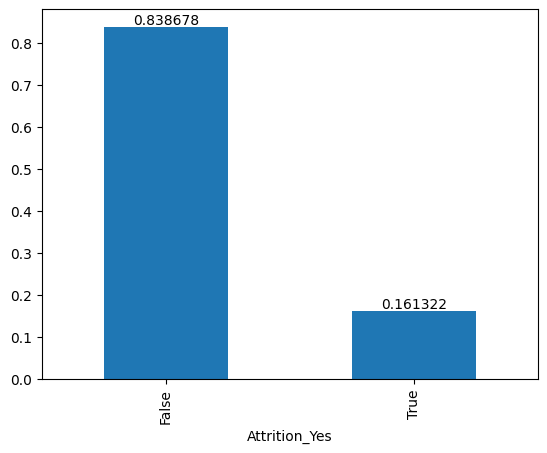

In [ ]:
# Training
ax = training['Attrition_Yes'].value_counts(normalize=True).plot(kind='bar')
ax.bar_label(ax.containers[0])

[Text(0, 0, '0.839002'), Text(0, 0, '0.160998')]

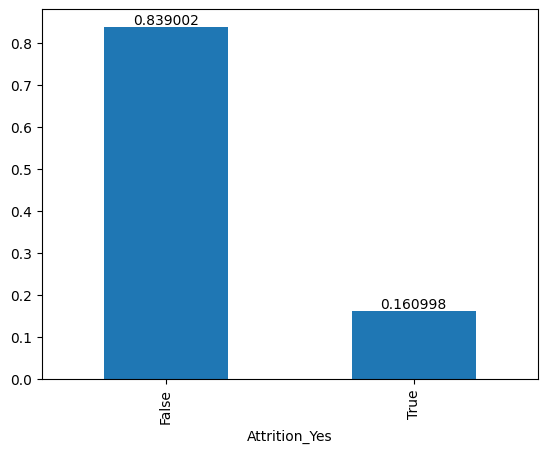

In [ ]:
# Test
ax = test['Attrition_Yes'].value_counts(normalize=True).plot(kind='bar')
ax.bar_label(ax.containers[0])

In [ ]:
binary_columns = training.columns[training.isin([0,1]).all(axis=0)]
binary_columns = list(set(binary_columns) - set(['Attrition']))
binary_columns

['Attrition_Yes', 'OverTime']

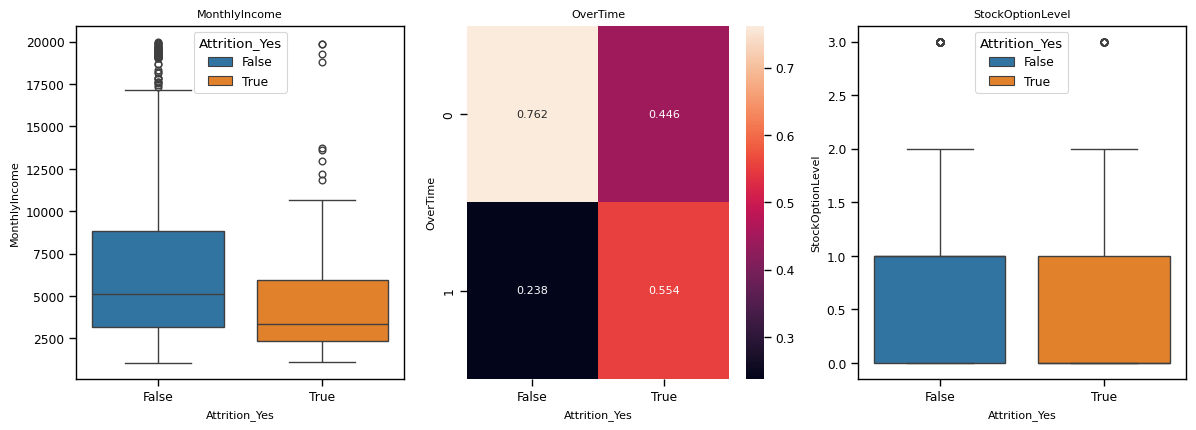

In [ ]:
# First, we create the figure and axis
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Get smaller font size
sns.set_context("paper", rc={"font.size":8,"axes.titlesize":8,"axes.labelsize":8})

for col, ax in zip(training.columns, axes.flatten()):

    # FIX 1: Skip the target variable so it doesn't plot against itself
    if col == 'Attrition_Yes':
        ax.set_visible(False)
        continue

    # FIX 2: Modern Pandas syntax for the OverTime heatmap
    if col in binary_columns:
        data = training[['Attrition_Yes', col]].groupby('Attrition_Yes').value_counts(normalize=True).reset_index(name='value').pivot(columns='Attrition_Yes', index=col, values='value')
        sns.heatmap(data, annot=True, fmt=",.3f", ax=ax)

    # Standard Boxplot for MonthlyIncome and StockOptionLevel
    else:
        sns.boxplot(data=training, x='Attrition_Yes', y=col, hue='Attrition_Yes', ax=ax)

    ax.set_title(col)

# FIX 3: Hide the extra empty squares at the bottom of the 2x3 grid
for i in range(len(training.columns), len(axes.flatten())):
    axes.flatten()[i].set_visible(False)

plt.tight_layout()

In [ ]:
#select the rows for corellation checking
corr_column = x_training.select_dtypes(include=[np.number]).columns.to_list()
corr_column

['MonthlyIncome', 'OverTime', 'StockOptionLevel']

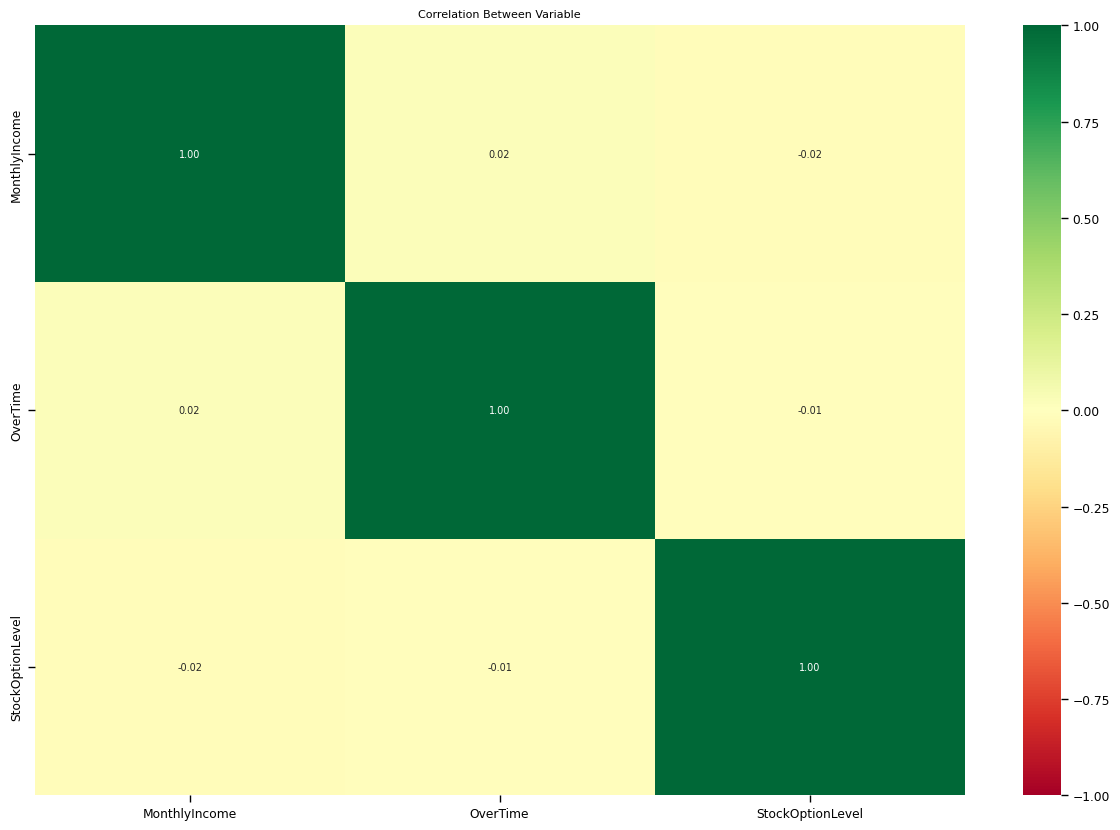

In [ ]:
#see the correlation in heatmap

fig = plt.figure(figsize=(15,10))

ax = fig.add_subplot(1, 1, 1)
ax.set_title('Correlation Between Variable')

sns.heatmap(x_training[corr_column].corr(),vmin=-1,
            vmax=1,cmap='RdYlGn',annot=True,
            annot_kws={"fontsize":7}, fmt=",.2f")

plt.show()

In [ ]:
# Class weight balanced terjadi karena datanya imbalanced (6% dari populasi ambil loan)
# Max_Iter : maximal berapa kali prediksi Logistic Regression diperbaiki
model = LogisticRegression(max_iter=500)
model.fit(x_training, y_training.ravel())

/tmp/ipykernel_1207/2878873073.py:4: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  model.fit(x_training, y_training.ravel())


LogisticRegression(max_iter=500)

#LOGISTIC REGRESSION RESULT & EVALUATION

##PROBABILITY AND THE PREDICTION (RESULT)

In [ ]:
x_training2 = x_training.copy()
x_training2['prediction'] = model.predict(x_training) # Prediction of leaving
x_training2[['prob_no','prob_leave']] = model.predict_proba(x_training) # Output probability to leave
x_training2[['prob_leave','prediction']]

,prob_leave,prediction
1447,0.094031,False
492,0.026625,False
1186,0.410538,False
833,0.132055,False
295,0.033944,False
...,...,...
2,0.492644,False
1327,0.035281,False
296,0.203964,False
1439,0.050408,False


In [ ]:
x_test2 = x_test.copy()
x_test2['prediction'] = model.predict(x_test)
x_test2[['prob_no','prob_leave']] = model.predict_proba(x_test)
x_test2[['prob_leave','prediction']]

,prob_leave,prediction
785,0.051115,False
1390,0.134707,False
1347,0.155687,False
319,0.389824,False
556,0.182559,False
...,...,...
321,0.035748,False
1281,0.371428,False
810,0.020350,False
49,0.186190,False


##EVALUATION

###CONFUSION MATRIX

In [ ]:
confusion_train = confusion_matrix(y_training, model.predict(x_training))
confusion_train

array([[863,   0],
       [163,   3]])

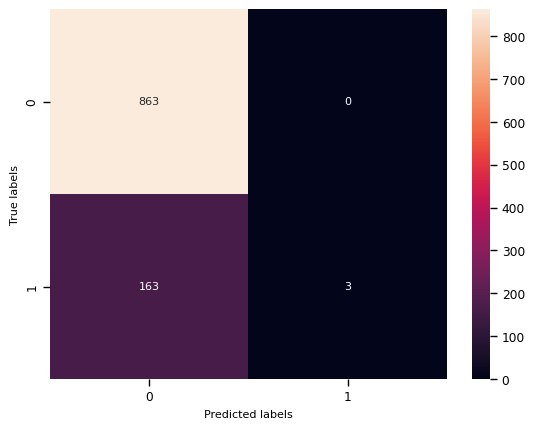

In [ ]:
ax = plt.subplot()
sns.heatmap(confusion_train, annot=True, fmt = 'd')
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');

###CLASSIFICATION REPORT

In [ ]:
print(classification_report(y_training, model.predict(x_training)))

              precision    recall  f1-score   support

       False       0.84      1.00      0.91       863
        True       1.00      0.02      0.04       166

    accuracy                           0.84      1029
   macro avg       0.92      0.51      0.47      1029
weighted avg       0.87      0.84      0.77      1029



In [ ]:
print(classification_report(y_test, model.predict(x_test)))

              precision    recall  f1-score   support

       False       0.84      1.00      0.91       370
        True       1.00      0.03      0.05        71

    accuracy                           0.84       441
   macro avg       0.92      0.51      0.48       441
weighted avg       0.87      0.84      0.78       441



###ROC

####TRAINING

In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()

# Create score from model
y_train_score = model.decision_function(x_training)

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_training, y_train_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

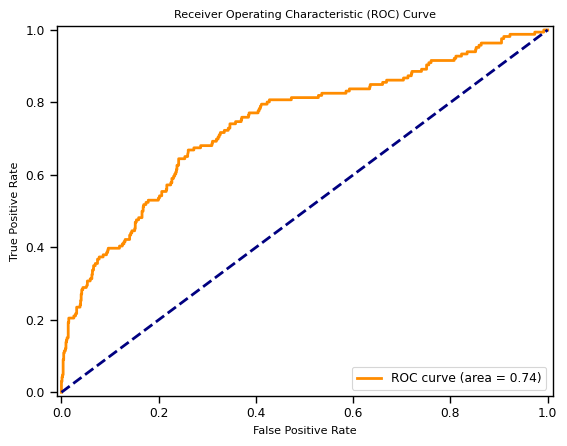

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
lw = 2
plt.plot(
    fpr["micro"],
    tpr["micro"],
    color = "darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc["micro"],
)
plt.plot([0,1],[0,1], color="navy", lw=lw, linestyle = '--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc = "lower right")
plt.show()

In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()

# Create score from model
y_test_score = model.decision_function(x_test)

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test, y_test_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

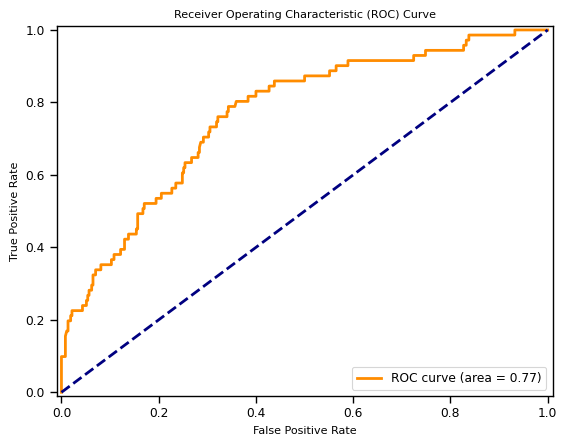

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
lw = 2
plt.plot(
    fpr["micro"],
    tpr["micro"],
    color = "darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc["micro"],
)
plt.plot([0,1],[0,1], color="navy", lw=lw, linestyle = '--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc = "lower right")
plt.show()

In [ ]:
# Create a prediction table for training set
x_training2 = x_training.copy()
x_training2['prediction'] = model.predict(x_training)
x_training2[['prob_no','prob_leave']] = model.predict_proba(x_training)
x_training2 = x_training2[['prob_leave','prediction']].copy()
x_training2

,prob_leave,prediction
1447,0.094031,False
492,0.026625,False
1186,0.410538,False
833,0.132055,False
295,0.033944,False
...,...,...
2,0.492644,False
1327,0.035281,False
296,0.203964,False
1439,0.050408,False


In [ ]:
x_training2 = x_training2.merge(y_training, how='inner', left_index=True, right_index=True)
x_training2

,prob_leave,prediction,Attrition_Yes
1447,0.094031,False,False
492,0.026625,False,False
1186,0.410538,False,True
833,0.132055,False,False
295,0.033944,False,False
...,...,...,...
2,0.492644,False,True
1327,0.035281,False,False
296,0.203964,False,True
1439,0.050408,False,False


In [ ]:
# Create 10 decile
x_training2['binning'] = pd.qcut(x_training2['prob_leave'], q=10, precision=5)

# Create proposition table (MODERN PANDAS FIX)
df_prop = x_training2.drop(['prob_leave', 'prediction'], axis=1).value_counts().sort_index(ascending=False).reset_index(name='count')

# Pivot the table using the new 'count' name
df_prop = df_prop.pivot(index='binning', columns='Attrition_Yes', values='count').fillna(0)

# Standardize column names to strict integers (0 and 1) so the author's math doesn't break
df_prop.columns = df_prop.columns.astype(int)

# The rest of the mathematical calculations
df_prop['total_obs'] = df_prop.sum(axis=1)
df_prop['prob_leave'] = df_prop[1] / df_prop['total_obs']
n_good = df_prop[df_prop.columns[0]].sum(axis=0)
n_bad = df_prop[df_prop.columns[1]].sum(axis=0)
df_prop['pct_non_leave'] = df_prop[df_prop.columns[0]] / n_good
df_prop['pct_leave'] = df_prop[df_prop.columns[1]] / n_bad
df_prop['cumm_non_leave'] = df_prop['pct_non_leave'].cumsum()
df_prop['cumm_leave'] = df_prop['pct_leave'].cumsum()

# Rename the final columns for the dashboard
df_prop = df_prop.rename(columns={0: '#non-leave', 1: '#leave'})

In [ ]:
# Q: Apakah benar ketika peluang leave itu semakin tinggi, memang semakin banyak orang yang leave?
df_prop

Attrition_Yes,#non-leave,#leave,total_obs,prob_leave,pct_non_leave,pct_leave,cumm_non_leave,cumm_leave
binning,,,,,,,,
"(0.0078228, 0.046508]",97,6,103,0.058252,0.112399,0.036145,0.112399,0.036145
"(0.046508, 0.066176]",95,8,103,0.077670,0.110081,0.048193,0.222480,0.084337
"(0.066176, 0.088161]",94,9,103,0.087379,0.108922,0.054217,0.331402,0.138554
"(0.088161, 0.10697]",97,6,103,0.058252,0.112399,0.036145,0.443801,0.174699
"(0.10697, 0.12972]",100,3,103,0.029126,0.115875,0.018072,0.559676,0.192771
"(0.12972, 0.14648]",88,14,102,0.137255,0.101970,0.084337,0.661645,0.277108
"(0.14648, 0.17741]",87,16,103,0.155340,0.100811,0.096386,0.762457,0.373494
"(0.17741, 0.2353]",74,29,103,0.281553,0.085747,0.174699,0.848204,0.548193
"(0.2353, 0.37054]",80,23,103,0.223301,0.092700,0.138554,0.940904,0.686747


###KS-TEST

In [ ]:
ks_statistics  = 100*(df_prop['cumm_non_leave'] - df_prop['cumm_leave']).max()
ks_statistics

38.896257102570196

#MERGE DATA AFTER REGRESSION

##INITIAL DATA

In [ ]:
ibm5 = pd.concat([training, test])
ibm5

,MonthlyIncome,OverTime,StockOptionLevel,Attrition_Yes
1447,5406,0,1,False
492,15402,0,1,False
1186,4581,1,0,True
833,2539,0,1,False
295,13525,0,1,False
...,...,...,...,...
321,7547,0,3,False
1281,5813,1,0,True
810,17465,0,1,False
49,2269,0,0,False


##PROBABILITY AND PREDICTION DATA

In [ ]:
x_training_merge = x_training2.copy()
x_training_merge.drop(['binning','Attrition_Yes'], axis=1, inplace=True)
x_training_merge

,prob_leave,prediction
1447,0.094031,False
492,0.026625,False
1186,0.410538,False
833,0.132055,False
295,0.033944,False
...,...,...
2,0.492644,False
1327,0.035281,False
296,0.203964,False
1439,0.050408,False


In [ ]:
x_test_merge = x_test.copy()
x_test_merge['prediction'] = model.predict(x_test)
x_test_merge[['prob_no','prob_leave']] = model.predict_proba(x_test)
x_test_merge = x_test_merge[['prob_leave','prediction']].copy()
x_test_merge

,prob_leave,prediction
785,0.051115,False
1390,0.134707,False
1347,0.155687,False
319,0.389824,False
556,0.182559,False
...,...,...
321,0.035748,False
1281,0.371428,False
810,0.020350,False
49,0.186190,False


In [ ]:
prob_pred = pd.concat([x_training_merge, x_test_merge])
prob_pred

,prob_leave,prediction
1447,0.094031,False
492,0.026625,False
1186,0.410538,False
833,0.132055,False
295,0.033944,False
...,...,...
321,0.035748,False
1281,0.371428,False
810,0.020350,False
49,0.186190,False


##MERGED INITIAL + PROBABILITY AND PREDICTION DATA

In [ ]:
ibm_merged = ibm.merge(prob_pred, how='left',left_index=True, right_index=True)
ibm_merged

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,prob_leave,prediction
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,8,0,1,6,4,0,5,0.365839,False
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,1,10,3,3,10,7,1,7,0.097215,False
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,0,7,3,3,0,0,0,0,0.492644,False
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,0,8,3,3,8,7,3,0,0.465384,False
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,1,6,3,3,2,2,2,2,0.118486,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,1,17,3,3,5,2,0,3,0.131566,False
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,9,5,3,7,7,1,7,0.053300,False
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,1,6,0,3,6,2,0,3,0.280513,False
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,0,17,3,2,9,6,0,8,0.131094,False


#PREDICTION WITH LOWER PROBABILITY
finding out the high potential existing employee (excluding the one who already left) to leave by lower the probability to 0.3

In [ ]:
#number of employee now
ibm_existing = ibm_merged.copy()
ibm_existing['prediction'].count()

np.int64(1470)

In [ ]:
#number of employee now
ibm_existing_nonleave = ibm_merged.loc[(ibm_merged['Attrition']==0)]
ibm_existing_nonleave['prediction'].count()

np.int64(0)

In [ ]:
#number of employee at high potential to leave
ibm_prob_leave = ibm_merged.loc[(ibm_merged['prob_leave'] > 0.3) & (ibm_merged['Attrition']==0)]
ibm_prob_leave['prob_leave'].count()

np.int64(0)

In [ ]:
#probability Attrition Rate
148/1205

0.12282157676348547

In [ ]:
#add new prediction in data set, lower the probability to 0.3
ibm_existing.loc[ibm_existing['prob_leave'] > 0.3, 'new_prediction'] = 1
ibm_existing.loc[ibm_existing['prob_leave'] < 0.3, 'new_prediction'] = 0
ibm_existing['new_prediction'] = ibm_existing['new_prediction'].astype(int)
ibm_existing['new_prediction'] = ibm_existing['new_prediction'].round()
ibm_existing

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,prob_leave,prediction,new_prediction
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,8,0,1,6,4,0,5,0.365839,False,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,10,3,3,10,7,1,7,0.097215,False,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,7,3,3,0,0,0,0,0.492644,False,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,8,3,3,8,7,3,0,0.465384,False,1
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,6,3,3,2,2,2,2,0.118486,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,17,3,3,5,2,0,3,0.131566,False,0
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,9,5,3,7,7,1,7,0.053300,False,0
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,6,0,3,6,2,0,3,0.280513,False,0
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,17,3,2,9,6,0,8,0.131094,False,0


#EMPLOYEE EVALUATION

In [ ]:
ibm_existing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [ ]:
#to exclude employee who left the company
ibm_existing = ibm_existing.loc[ibm_existing['Attrition']==0]

##OVERTIME
Overtime only applied in level 1 & 2 and if it urgently needed

In [ ]:
# FIX 1: Correctly filter for existing employees (Attrition_Yes == 0)
ibm_existing = ibm3[ibm3['Attrition_Yes'] == 0].copy()

# Apply the TalentGuard HR Strategy: Overtime only for Level 1 & 2 in urgent cases
ibm_existing.loc[ibm_existing['JobLevel'] < 3, 'new_overtime'] = ibm_existing['OverTime']
ibm_existing.loc[ibm_existing['JobLevel'] > 2, 'new_overtime'] = 0

In [ ]:
# Check the results
print(ibm_existing['new_overtime'].value_counts())

# Calculate the financial impact (reduction in overtime)
reduction = ibm_existing['new_overtime'].sum() / ibm_existing['OverTime'].sum()
print(f"\nOvertime Reduction Ratio: {reduction:.4f}")

new_overtime
0.0    1039
1.0     194
Name: count, dtype: int64

Overtime Reduction Ratio: 0.6713


##SALARY
- if the performance rating 1 = 2% salary increasement
- if the performance rating 2 = 3% salary increasement
- if the performance rating 3 = 4% salary increasement
- if the performance rating 4 = 5% salary increasement


- if the job involvement rating 1 = 2% salary increasement
- if the job involvement rating 2 = 3% salary increasement
- if the job involvement rating 3 = 4% salary increasement
- if the job involvement rating 4 = 5% salary increasement


- if the performance rating 4 + job involvement 4 + training>1 = promotion 15% salary increasement

In [ ]:
# FIX 1: Fetch the dropped columns from the original encoded dataset (ibm2)
ibm_existing['PerformanceRating'] = ibm2['PerformanceRating']
ibm_existing['TrainingTimesLastYear'] = ibm2['TrainingTimesLastYear']

# Apply the TalentGuard Promotion Strategy
ibm_existing.loc[(ibm_existing['PerformanceRating'] == 4) & (ibm_existing['JobInvolvement'] > 2) & (ibm_existing['TrainingTimesLastYear'] > 1) , 'inc_promotion'] = 0.15

# Clean missing values using modern Pandas syntax (avoiding inplace=True)
ibm_existing['inc_promotion'] = ibm_existing['inc_promotion'].fillna(0)

# Check the result
print(ibm_existing['inc_promotion'].value_counts())

inc_promotion
0.00    1114
0.15     119
Name: count, dtype: int64


In [ ]:
#performance rating
ibm_existing.loc[ibm_existing['PerformanceRating'] == 1 , 'inc_performance'] = 0.02
ibm_existing.loc[ibm_existing['PerformanceRating'] == 2 , 'inc_performance'] = 0.03
ibm_existing.loc[ibm_existing['PerformanceRating'] == 3 , 'inc_performance'] = 0.04
ibm_existing.loc[ibm_existing['PerformanceRating'] == 4 , 'inc_performance'] = 0.05
ibm_existing.loc[ibm_existing['inc_promotion'] == 0.15 , 'inc_performance'] = 0
ibm_existing['inc_performance'].value_counts()

,count
inc_performance,
0.04,1044
0.00,119
0.05,70


In [ ]:
#job involvement
ibm_existing.loc[ibm_existing['JobInvolvement'] == 1 , 'inc_involvement'] = 0.02
ibm_existing.loc[ibm_existing['JobInvolvement'] == 2 , 'inc_involvement'] = 0.03
ibm_existing.loc[ibm_existing['JobInvolvement'] == 3 , 'inc_involvement'] = 0.04
ibm_existing.loc[ibm_existing['JobInvolvement'] == 4 , 'inc_involvement'] = 0.05
ibm_existing.loc[ibm_existing['inc_promotion'] == 0.15 , 'inc_involvement'] = 0
ibm_existing['inc_involvement'].value_counts()

,count
inc_involvement,
0.04,641
0.03,304
0.00,119
0.05,114
0.02,55


In [ ]:
ibm_existing['MonthlyIncome'].mean()

np.float64(6832.739659367397)

In [ ]:
ibm_existing['new_salary'] = (ibm_existing['inc_promotion'] + ibm_existing['inc_performance'] + ibm_existing['inc_involvement'] + 1 ) * ibm_existing['MonthlyIncome']
(ibm_existing['new_salary'].mean())/(ibm_existing['MonthlyIncome'].mean())

np.float64(1.0842341486436184)

In [ ]:
ibm_existing.loc[(ibm_existing['JobLevel'] < 5) & (ibm_existing['inc_promotion'] == 0.15) , 'inc_involvement'] = (ibm_existing['JobLevel'] + 1)

##STOCK OPTION
- if performance rating 4 = +1
- if job involvement >2 = +1
- if working more than 5 years = +1
- if job level >3 = +1

In [ ]:
#performance rating
ibm_existing.loc[ibm_existing['PerformanceRating'] == 4 , 'stock_performance'] = 1
ibm_existing.loc[ibm_existing['PerformanceRating'] < 4 , 'stock_performance'] = 0
ibm_existing['stock_performance'].value_counts()

,count
stock_performance,
0.0,1044
1.0,189


In [ ]:
#job involvement
ibm_existing.loc[ibm_existing['JobInvolvement'] == 4 , 'stock_involvement'] = 1
ibm_existing.loc[ibm_existing['JobInvolvement'] < 4 , 'stock_involvement'] = 0
ibm_existing['stock_involvement'].value_counts()

,count
stock_involvement,
0.0,1102
1.0,131


In [ ]:
#total working years
ibm_existing.loc[ibm_existing['TotalWorkingYears'] > 5 , 'stock_years'] = 1
ibm_existing.loc[ibm_existing['TotalWorkingYears'] < 6 , 'stock_years'] = 0
ibm_existing['stock_years'].value_counts()

,count
stock_years,
1.0,1008
0.0,225


In [ ]:
#job level
#ibm_existing.loc[ibm_existing['JobLevel'] > 4 , 'stock_level'] = 1
#ibm_existing.loc[ibm_existing['JobLevel'] < 5 , 'stock_level'] = 0
#ibm_existing['stock_level'].value_counts()

In [ ]:
ibm_existing['new_stock_op'] = ibm_existing['stock_performance'] + ibm_existing['stock_involvement'] + ibm_existing['stock_years']
(ibm_existing['new_stock_op'].sum())/(ibm_existing['StockOptionLevel'].sum())

np.float64(1.2744721689059502)

##CREATE NEW DATAFRAME CONSIST OF NEW VALUE


In [ ]:
ibm_existing

,Age,JobLevel,MonthlyIncome,OverTime,TotalWorkingYears,StockOptionLevel,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,JobRole_Sales Representative,...,PerformanceRating,TrainingTimesLastYear,inc_promotion,inc_performance,inc_involvement,new_salary,stock_performance,stock_involvement,stock_years,new_stock_op
1,49,2,5130,0,10,1,10,7,7,False,...,4,3,0.00,0.05,0.03,5540.40,1.0,0.0,1.0,2.0
3,33,1,2909,1,8,0,8,7,0,False,...,3,3,0.00,0.04,0.04,3141.72,0.0,0.0,1.0,1.0
4,27,1,3468,0,6,1,2,2,2,False,...,3,3,0.00,0.04,0.04,3745.44,0.0,0.0,1.0,1.0
5,32,1,3068,0,8,0,7,7,6,False,...,3,2,0.00,0.04,0.04,3313.44,0.0,0.0,1.0,1.0
6,59,1,2670,1,12,3,1,0,0,False,...,4,3,0.15,0.00,2.00,3070.50,1.0,1.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,2,2571,0,17,1,5,2,3,False,...,3,3,0.00,0.04,0.05,2802.39,0.0,1.0,1.0,2.0
1466,39,3,9991,0,9,1,7,7,7,False,...,3,5,0.00,0.04,0.03,10690.37,0.0,0.0,1.0,1.0
1467,27,2,6142,1,6,1,6,2,3,False,...,4,0,0.00,0.05,0.05,6756.20,1.0,1.0,1.0,3.0
1468,49,2,5390,0,17,0,9,6,8,False,...,3,3,0.00,0.04,0.03,5767.30,0.0,0.0,1.0,1.0


In [ ]:
columns_to_select_and_rename = {
    'new_salary' : 'MonthlyIncome',
    'new_overtime' : 'OverTime',
    'new_stock_op' : 'StockOptionLevel'
}

# Create a new DataFrame with selected and renamed columns
ibm_impact = ibm_existing[list(columns_to_select_and_rename.keys())].rename(columns=columns_to_select_and_rename)
ibm_impact

,MonthlyIncome,OverTime,StockOptionLevel
1,5540.40,0.0,2.0
3,3141.72,1.0,1.0
4,3745.44,0.0,1.0
5,3313.44,0.0,1.0
6,3070.50,1.0,3.0
...,...,...,...
1465,2802.39,0.0,2.0
1466,10690.37,0.0,1.0
1467,6756.20,1.0,3.0
1468,5767.30,0.0,1.0


#IMPACT ANALYSIS (LOGISTIC REGRESSION)

##PROBABILITY AND THE PREDICTION (RESULT)

In [ ]:
ibm_impact2 = ibm_impact.copy()
ibm_impact2['prediction'] = model.predict(ibm_impact) # Prediction of leaving
ibm_impact2[['prob_no_impact','prob_leave_impact']] = model.predict_proba(ibm_impact) # Output probability to leave
ibm_impact2

,MonthlyIncome,OverTime,StockOptionLevel,prediction,prob_no_impact,prob_leave_impact
1,5540.40,0.0,2.0,False,0.934333,0.065667
3,3141.72,1.0,1.0,False,0.632199,0.367801
4,3745.44,0.0,1.0,False,0.885325,0.114675
5,3313.44,0.0,1.0,False,0.879343,0.120657
6,3070.50,1.0,3.0,False,0.781773,0.218227
...,...,...,...,...,...,...
1465,2802.39,0.0,2.0,False,0.908044,0.091956
1466,10690.37,0.0,1.0,False,0.951216,0.048784
1467,6756.20,1.0,3.0,False,0.854174,0.145826
1468,5767.30,0.0,1.0,False,0.909996,0.090004


##MAKING NEW COLUMN WITH LOWER PROBABILITY
lower probability = 0.3

In [ ]:
ibm_impact2.loc[(ibm_impact2['prob_leave_impact']>0.3)]

,MonthlyIncome,OverTime,StockOptionLevel,prediction,prob_no_impact,prob_leave_impact
3,3141.72,1.0,1.0,False,0.632199,0.367801
11,4486.51,1.0,1.0,False,0.672842,0.327158
17,3199.15,1.0,1.0,False,0.633979,0.366021
19,4259.52,1.0,1.0,False,0.666141,0.333859
38,3658.33,1.0,1.0,False,0.648074,0.351926
...,...,...,...,...,...,...
1422,2872.80,1.0,0.0,False,0.533414,0.466586
1425,5268.24,1.0,1.0,False,0.695371,0.304629
1435,2630.88,1.0,1.0,False,0.616216,0.383784
1436,2570.40,1.0,0.0,False,0.523362,0.476638


In [ ]:
ibm_impact2.loc[ibm_impact2['prob_leave_impact'] > 0.3, 'new_prediction_impact'] = 1
ibm_impact2['new_prediction_impact'] = ibm_impact2['new_prediction_impact'].fillna(0)
ibm_impact2['new_prediction_impact'] = ibm_impact2['new_prediction_impact'].astype(int)
ibm_impact2['new_prediction_impact'] = ibm_impact2['new_prediction_impact'].round()
ibm_impact2

,MonthlyIncome,OverTime,StockOptionLevel,prediction,prob_no_impact,prob_leave_impact,new_prediction_impact
1,5540.40,0.0,2.0,False,0.934333,0.065667,0
3,3141.72,1.0,1.0,False,0.632199,0.367801,1
4,3745.44,0.0,1.0,False,0.885325,0.114675,0
5,3313.44,0.0,1.0,False,0.879343,0.120657,0
6,3070.50,1.0,3.0,False,0.781773,0.218227,0
...,...,...,...,...,...,...,...
1465,2802.39,0.0,2.0,False,0.908044,0.091956,0
1466,10690.37,0.0,1.0,False,0.951216,0.048784,0
1467,6756.20,1.0,3.0,False,0.854174,0.145826,0
1468,5767.30,0.0,1.0,False,0.909996,0.090004,0


In [ ]:
ibm_impact2['new_prediction_impact'].count()

np.int64(1233)

In [ ]:
ibm_impact2['new_prediction_impact'].sum()

np.int64(97)

In [ ]:
106/1205

0.08796680497925312

#inserting the impact analysis result to main data frame

In [ ]:
ibm_existing

,Age,JobLevel,MonthlyIncome,OverTime,TotalWorkingYears,StockOptionLevel,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,JobRole_Sales Representative,...,PerformanceRating,TrainingTimesLastYear,inc_promotion,inc_performance,inc_involvement,new_salary,stock_performance,stock_involvement,stock_years,new_stock_op
1,49,2,5130,0,10,1,10,7,7,False,...,4,3,0.00,0.05,0.03,5540.40,1.0,0.0,1.0,2.0
3,33,1,2909,1,8,0,8,7,0,False,...,3,3,0.00,0.04,0.04,3141.72,0.0,0.0,1.0,1.0
4,27,1,3468,0,6,1,2,2,2,False,...,3,3,0.00,0.04,0.04,3745.44,0.0,0.0,1.0,1.0
5,32,1,3068,0,8,0,7,7,6,False,...,3,2,0.00,0.04,0.04,3313.44,0.0,0.0,1.0,1.0
6,59,1,2670,1,12,3,1,0,0,False,...,4,3,0.15,0.00,2.00,3070.50,1.0,1.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,2,2571,0,17,1,5,2,3,False,...,3,3,0.00,0.04,0.05,2802.39,0.0,1.0,1.0,2.0
1466,39,3,9991,0,9,1,7,7,7,False,...,3,5,0.00,0.04,0.03,10690.37,0.0,0.0,1.0,1.0
1467,27,2,6142,1,6,1,6,2,3,False,...,4,0,0.00,0.05,0.05,6756.20,1.0,1.0,1.0,3.0
1468,49,2,5390,0,17,0,9,6,8,False,...,3,3,0.00,0.04,0.03,5767.30,0.0,0.0,1.0,1.0


In [ ]:
# Create the base dataframe
ibm_fix = ibm_merged.copy()

# Dynamically check which strategic columns you have actually created so far
target_columns = ['new_prediction', 'new_salary', 'new_overtime', 'new_stock_op', 'inc_promotion']
available_cols = [col for col in target_columns if col in ibm_existing.columns]

print(f"Successfully found and merging: {available_cols}")

# Merge only the available columns to prevent the KeyError
ibm_fix = ibm_fix.merge(ibm_existing[available_cols], left_index=True, right_index=True, how='left')

# Attempt to merge the impact dataframe if it exists
try:
    ibm_fix = ibm_fix.merge(ibm_impact2[['new_prediction_impact', 'prob_leave_impact']], left_index=True, right_index=True, how='left')
except NameError:
    print("Skipping ibm_impact2 merge: Dataframe not found yet.")
except KeyError:
    print("Skipping ibm_impact2 merge: Impact columns not found yet.")

# Check the current state of your final dataframe
ibm_fix.info()

Successfully found and merging: ['new_salary', 'new_overtime', 'new_stock_op', 'inc_promotion']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 43 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate            

In [ ]:
ibm_fix.loc[ibm_fix['Attrition']==0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 43 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       0 non-null      int64  
 1   Attrition                 0 non-null      object 
 2   BusinessTravel            0 non-null      object 
 3   DailyRate                 0 non-null      int64  
 4   Department                0 non-null      object 
 5   DistanceFromHome          0 non-null      int64  
 6   Education                 0 non-null      int64  
 7   EducationField            0 non-null      object 
 8   EmployeeCount             0 non-null      int64  
 9   EmployeeNumber            0 non-null      int64  
 10  EnvironmentSatisfaction   0 non-null      int64  
 11  Gender                    0 non-null      object 
 12  HourlyRate                0 non-null      int64  
 13  JobInvolvement            0 non-null      int64  
 14  JobLevel                  0

In [ ]:
#make it to from excel :

output_file = 'ibm_fix.xlsx'
ibm_fix.to_excel(output_file, index=False)  # Setting 'index=False' removes the index column in the Excel file